# Crop Yield Model Training and Comparison

This notebook trains and compares **Random Forest**, **Gradient Boosting**, and **XGBoost** on the merged dataset, then saves the best model for prediction.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from xgboost import XGBRegressor
import joblib

pd.set_option('display.max_columns', 200)

In [2]:
root_dir = Path.cwd()
dataset_path = root_dir / 'outputs' / 'merged_crop_dataset.csv'

if not dataset_path.exists():
    raise FileNotFoundError(f'Merged dataset not found at: {dataset_path}')

df = pd.read_csv(dataset_path)
print(f'Dataset shape: {df.shape}')
display(df.head(3))

Dataset shape: (28809, 21)


,State,District,Crop,Year,Season,Area,Production,Yield,Annual_Rainfall,Fertilizer,Pesticide,Nitrogen_Requirement,Phosphorus_Requirement,Yield_per_Area,Fertilizer_per_Area,Pesticide_per_Area,Temperature_C,Humidity,pH,Wind_Speed,Solar_Radiation
0,andaman and nicobar island,nicobars,arecanut,2000,kharif,1254.0,2000.0,1.59,1213.3,1234957.44,2421.9,45.00009,20.62374,1.594896,984.814545,1.931340,22.0,70.0,6.0,2.5,20.0
1,andaman and nicobar island,north and middle andaman,arecanut,2000,kharif,3100.0,5200.0,1.68,1213.3,1234957.44,2421.9,45.00009,20.62374,1.677419,398.373368,0.781258,22.0,70.0,6.0,2.5,20.0
2,andaman and nicobar island,nicobars,arecanut,2001,kharif,1254.0,2061.0,1.64,1213.3,1234957.44,2421.9,45.00009,20.62374,1.643541,984.814545,1.931340,22.0,70.0,6.0,2.5,20.0


In [3]:
target_col = 'Yield'
if target_col not in df.columns:
    raise ValueError('Yield column missing in merged dataset.')

feature_cols = [c for c in df.columns if c != target_col]
X = df[feature_cols].copy()
y = pd.to_numeric(df[target_col], errors='coerce')

# Keep only valid target rows
valid_idx = y.notna()
X = X.loc[valid_idx].reset_index(drop=True)
y = y.loc[valid_idx].reset_index(drop=True)

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = [c for c in X.columns if c not in categorical_cols]

print('Categorical columns:', categorical_cols)
print('Numeric columns count:', len(numeric_cols))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def make_ohe():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
            ('onehot', make_ohe())
        ]), categorical_cols),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_cols),
    ],
    remainder='drop'
)

Categorical columns: ['State', 'District', 'Crop', 'Season']
Numeric columns count: 16


C:\Users\basui\AppData\Local\Temp\ipykernel_15624\1313884699.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


In [4]:
models = {
    'RandomForest': RandomForestRegressor(
        n_estimators=350,
        max_depth=None,
        min_samples_split=2,
        random_state=42,
        n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    'XGBoost': XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    )
}

results = []
trained_pipelines = {}

for model_name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    results.append({
        'Model': model_name,
        'R2': round(r2, 6),
        'MAE': round(mae, 6),
        'RMSE': round(rmse, 6)
    })
    trained_pipelines[model_name] = pipeline

results_df = pd.DataFrame(results).sort_values(by='R2', ascending=False).reset_index(drop=True)
display(results_df)

,Model,R2,MAE,RMSE
0,XGBoost,0.981064,0.040053,0.111996
1,GradientBoosting,0.978180,0.042991,0.120221
2,RandomForest,0.976342,0.039025,0.125183


In [5]:
best_model_name = results_df.iloc[0]['Model']
best_pipeline = trained_pipelines[best_model_name]

models_dir = root_dir / 'outputs' / 'models'
models_dir.mkdir(parents=True, exist_ok=True)

best_model_path = models_dir / 'best_crop_yield_model.joblib'
joblib.dump(best_pipeline, best_model_path)

metrics_path = root_dir / 'outputs' / 'model_comparison_scores.csv'
results_df.to_csv(metrics_path, index=False)

print(f'Best model: {best_model_name}')
print(f'Saved best model to: {best_model_path}')
print(f'Saved scores to: {metrics_path}')

Best model: XGBoost
Saved best model to: c:\Users\basui\OneDrive\Documents\ONE DRIVE AUTOCAD\OneDrive\Desktop\Crop Prediction Model\CROP YIELD MODEL\outputs\models\best_crop_yield_model.joblib
Saved scores to: c:\Users\basui\OneDrive\Documents\ONE DRIVE AUTOCAD\OneDrive\Desktop\Crop Prediction Model\CROP YIELD MODEL\outputs\model_comparison_scores.csv


C:\Users\basui\AppData\Local\Temp\ipykernel_15624\1506288023.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='R2', palette='viridis')


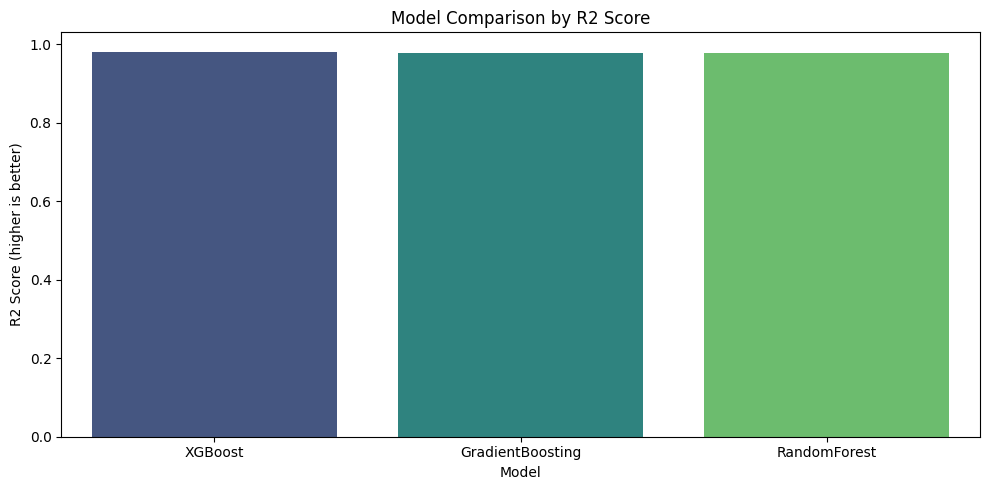

Saved chart to: c:\Users\basui\OneDrive\Documents\ONE DRIVE AUTOCAD\OneDrive\Desktop\Crop Prediction Model\CROP YIELD MODEL\outputs\model_comparison_r2.png


In [6]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='Model', y='R2', palette='viridis')
plt.title('Model Comparison by R2 Score')
plt.ylabel('R2 Score (higher is better)')
plt.xlabel('Model')
plt.tight_layout()
plot_path = root_dir / 'outputs' / 'model_comparison_r2.png'
plt.savefig(plot_path, dpi=200)
plt.show()
print(f'Saved chart to: {plot_path}')

## Advanced Models And Robust Evaluation

This section extends the baseline comparison with **CatBoost**, **LightGBM**, **ExtraTrees**, **HistGradientBoosting**, and **Stacking**.

It also reports:
- overall metrics (R2, MAE, RMSE)
- mean crop-wise MAE
- mean state-wise MAE

Then it saves the best advanced model and score tables.

In [7]:
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import RidgeCV
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

# Refit preprocessing once to produce a shared feature matrix for all advanced models.
X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)

advanced_models = {
    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1,
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=10,
        max_iter=400,
        random_state=42,
    ),
    "CatBoost": CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=8,
        loss_function="RMSE",
        random_seed=42,
        verbose=False,
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=600,
        learning_rate=0.05,
        num_leaves=63,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
    ),
    "XGBoost_v2": XGBRegressor(
        n_estimators=700,
        learning_rate=0.04,
        max_depth=8,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    ),
}

stacking = StackingRegressor(
    estimators=[
        ("lgbm", LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42)),
        ("xgb", XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=7, objective="reg:squarederror", random_state=42, n_jobs=-1)),
        ("etr", ExtraTreesRegressor(n_estimators=250, random_state=42, n_jobs=-1)),
    ],
    final_estimator=RidgeCV(alphas=(0.1, 1.0, 10.0)),
    passthrough=False,
    n_jobs=-1,
)
advanced_models["Stacking"] = stacking

In [8]:
def grouped_mae(y_true, y_pred, group_series):
    eval_df = pd.DataFrame({"group": group_series, "y_true": y_true, "y_pred": y_pred})
    return (
        eval_df.groupby("group", dropna=False)
        .apply(lambda d: mean_absolute_error(d["y_true"], d["y_pred"]))
        .mean()
    )

adv_results = []
adv_fitted_models = {}

for model_name, model in advanced_models.items():
    model.fit(X_train_t, y_train)
    preds = model.predict(X_test_t)

    adv_results.append(
        {
            "Model": model_name,
            "R2": round(r2_score(y_test, preds), 6),
            "MAE": round(mean_absolute_error(y_test, preds), 6),
            "RMSE": round(np.sqrt(mean_squared_error(y_test, preds)), 6),
            "Mean_Crop_MAE": round(grouped_mae(y_test, preds, X_test["Crop"]), 6),
            "Mean_State_MAE": round(grouped_mae(y_test, preds, X_test["State"]), 6),
        }
    )
    adv_fitted_models[model_name] = model

advanced_results_df = pd.DataFrame(adv_results).sort_values(by="R2", ascending=False).reset_index(drop=True)
display(advanced_results_df)

best_adv_name = advanced_results_df.iloc[0]["Model"]
best_adv_model = adv_fitted_models[best_adv_name]

# Save best advanced model with preprocessing for direct inference.
best_advanced_bundle = {
    "preprocessor": preprocessor,
    "model": best_adv_model,
    "model_name": best_adv_name,
    "features": feature_cols,
}

advanced_scores_path = root_dir / "outputs" / "advanced_model_scores.csv"
advanced_bundle_path = root_dir / "outputs" / "models" / "best_advanced_crop_yield_model.joblib"

(root_dir / "outputs" / "models").mkdir(parents=True, exist_ok=True)
advanced_results_df.to_csv(advanced_scores_path, index=False)
joblib.dump(best_advanced_bundle, advanced_bundle_path)

print(f"Best advanced model: {best_adv_name}")
print(f"Saved advanced scores to: {advanced_scores_path}")
print(f"Saved best advanced bundle to: {advanced_bundle_path}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000957 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2536
[LightGBM] [Info] Number of data points in the train set: 23047, number of used features: 153
[LightGBM] [Info] Start training from score 1.076346


c:\Users\basui\OneDrive\Documents\ONE DRIVE AUTOCAD\OneDrive\Desktop\Crop Prediction Model\CROP YIELD MODEL\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\basui\OneDrive\Documents\ONE DRIVE AUTOCAD\OneDrive\Desktop\Crop Prediction Model\CROP YIELD MODEL\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Model,R2,MAE,RMSE,Mean_Crop_MAE,Mean_State_MAE
0,CatBoost,0.982261,0.042643,0.108399,0.051161,0.067752
1,Stacking,0.981702,0.038734,0.110092,0.045996,0.065905
2,LightGBM,0.981688,0.041656,0.110134,0.050901,0.071614
3,XGBoost_v2,0.981260,0.039660,0.111414,0.046356,0.064458
4,HistGradientBoosting,0.981057,0.042853,0.112017,0.052148,0.070281
5,ExtraTrees,0.975883,0.037764,0.126392,0.046714,0.068509


Best advanced model: CatBoost
Saved advanced scores to: c:\Users\basui\OneDrive\Documents\ONE DRIVE AUTOCAD\OneDrive\Desktop\Crop Prediction Model\CROP YIELD MODEL\outputs\advanced_model_scores.csv
Saved best advanced bundle to: c:\Users\basui\OneDrive\Documents\ONE DRIVE AUTOCAD\OneDrive\Desktop\Crop Prediction Model\CROP YIELD MODEL\outputs\models\best_advanced_crop_yield_model.joblib


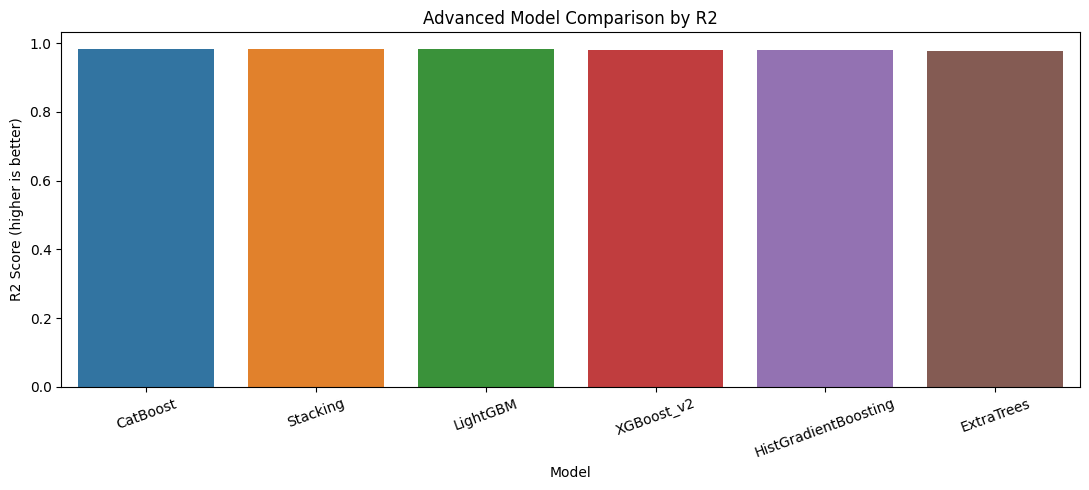

Saved advanced comparison chart to: c:\Users\basui\OneDrive\Documents\ONE DRIVE AUTOCAD\OneDrive\Desktop\Crop Prediction Model\CROP YIELD MODEL\outputs\advanced_model_comparison_r2.png


In [9]:
plt.figure(figsize=(11, 5))
ax = sns.barplot(data=advanced_results_df, x="Model", y="R2", hue="Model", dodge=False, legend=False)
ax.set_title("Advanced Model Comparison by R2")
ax.set_xlabel("Model")
ax.set_ylabel("R2 Score (higher is better)")
plt.xticks(rotation=20)
plt.tight_layout()

advanced_plot_path = root_dir / "outputs" / "advanced_model_comparison_r2.png"
plt.savefig(advanced_plot_path, dpi=200)
plt.show()
print(f"Saved advanced comparison chart to: {advanced_plot_path}")